In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


In [2]:
pip install openpyxl

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd

# Load Excel file
data = pd.read_excel("temperature_data.xlsm", engine="openpyxl")

data.head()


,Formatted_Date,Summary,Precip_Type,Temperature (C),Apparent_Temperature_C,Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251,15.8263,0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259,15.8263,0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204,14.9569,0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269,15.8263,0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259,15.8263,0,1016.51,Partly cloudy throughout the day.


In [4]:
data['Formatted_Date'] = pd.to_datetime(data['Formatted_Date'], utc=True)
data['Month'] = data['Formatted_Date'].dt.month

data[['Formatted_Date', 'Month', 'Temperature (C)']].head()


,Formatted_Date,Month,Temperature (C)
0,2006-03-31 22:00:00+00:00,3,9.472222
1,2006-03-31 23:00:00+00:00,3,9.355556
2,2006-04-01 00:00:00+00:00,4,9.377778
3,2006-04-01 01:00:00+00:00,4,8.288889
4,2006-04-01 02:00:00+00:00,4,8.755556


In [5]:
monthly_avg = data.groupby('Month')['Temperature (C)'].mean().reset_index()
monthly_avg


,Month,Temperature (C)
0,1,0.815678
1,2,2.166880
2,3,6.914976
3,4,12.769200
4,5,16.874455
5,6,20.728510
6,7,22.965462
7,8,22.339134
8,9,17.503458
9,10,11.334119


In [6]:
months = monthly_avg['Month'].values
temps = monthly_avg['Temperature (C)'].values

months, temps


(array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12]),
 array([ 0.81567761,  2.16687954,  6.91497638, 12.76920034, 16.8744549 ,
        20.7285101 , 22.96546198, 22.33913391, 17.50345819, 11.33411874,
         6.5875491 ,  1.62508621]))

In [7]:
x_mean = np.mean(months)
y_mean = np.mean(temps)

b1 = np.sum((months - x_mean) * (temps - y_mean)) / np.sum((months - x_mean) ** 2)
b0 = y_mean - b1 * x_mean

print("Intercept (b0):", b0)
print("Slope (b1):", b1)


Intercept (b0): 9.11433477807801
Slope (b1): 0.4263139699903405


In [8]:
y_pred = b0 + b1 * months
y_pred


array([ 9.54064875,  9.96696272, 10.39327669, 10.81959066, 11.24590463,
       11.6722186 , 12.09853257, 12.52484654, 12.95116051, 13.37747448,
       13.80378845, 14.23010242])

In [9]:
mse = np.mean((temps - y_pred) ** 2)
mae = np.mean(np.abs(temps - y_pred))
r2 = 1 - (np.sum((temps - y_pred) ** 2) / np.sum((temps - y_mean) ** 2))

print("MSE:", mse)
print("MAE:", mae)
print("R-Square:", r2)


MSE: 59.73605132962994
MAE: 6.977994319466213
R-Square: 0.03498730067520717


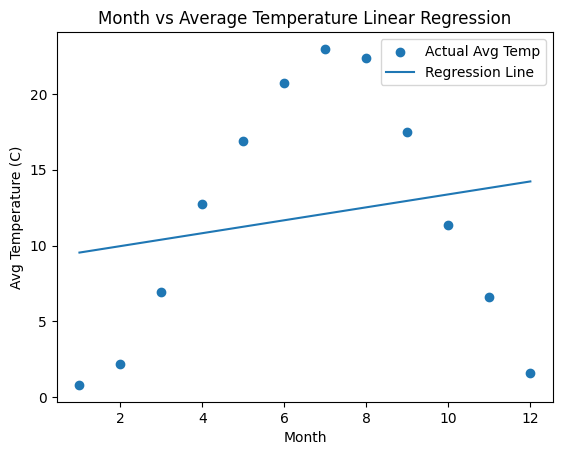

In [10]:
plt.scatter(months, temps, label="Actual Avg Temp")
plt.plot(months, y_pred, label="Regression Line")
plt.xlabel("Month")
plt.ylabel("Avg Temperature (C)")
plt.title("Month vs Average Temperature Linear Regression")
plt.legend()
plt.show()


In [11]:
# Original months
X = months

# Create polynomial terms
X_poly = np.column_stack((np.ones(len(X)), X, X**2))
X_poly[:5]


array([[ 1.,  1.,  1.],
       [ 1.,  2.,  4.],
       [ 1.,  3.,  9.],
       [ 1.,  4., 16.],
       [ 1.,  5., 25.]])

In [12]:
Y = temps.reshape(-1,1)

B = np.linalg.inv(X_poly.T @ X_poly) @ X_poly.T @ Y
B


array([[-12.17177486],
       [  9.54893238],
       [ -0.70173988]])

In [13]:
y_pred_poly = X_poly @ B
y_pred_poly = y_pred_poly.flatten()
y_pred_poly


array([-3.32458235,  4.1191304 , 10.1593634 , 14.79611663, 18.02939012,
       19.85918384, 20.28549781, 19.30833203, 16.92768648, 13.14356119,
        7.95595613,  1.36487132])

In [14]:
mse = np.mean((temps - y_pred_poly) ** 2)
mae = np.mean(np.abs(temps - y_pred_poly))
r2 = 1 - (np.sum((temps - y_pred_poly) ** 2) / np.sum((temps - np.mean(temps)) ** 2))

print("Polynomial Regression Results")
print("MSE:", mse)
print("MAE:", mae)
print("R-Square:", r2)


Polynomial Regression Results
MSE: 4.965907403119517
MAE: 1.926056477749075
R-Square: 0.9197776953612541


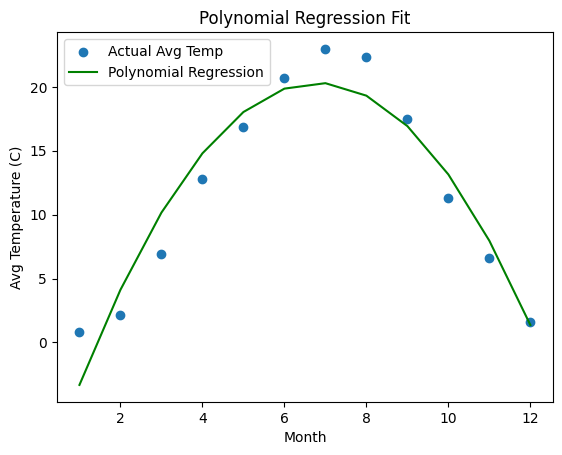

In [15]:
plt.scatter(months, temps, label="Actual Avg Temp")
plt.plot(months, y_pred_poly, label="Polynomial Regression", color='green')
plt.xlabel("Month")
plt.ylabel("Avg Temperature (C)")
plt.title("Polynomial Regression Fit")
plt.legend()
plt.show()


In [16]:
X = months
Y = temps.reshape(-1,1)

sin_term = np.sin(2 * np.pi * X / 12)
cos_term = np.cos(2 * np.pi * X / 12)

X_seasonal = np.column_stack((np.ones(len(X)), sin_term, cos_term))
X_seasonal[:5]


array([[ 1.00000000e+00,  5.00000000e-01,  8.66025404e-01],
       [ 1.00000000e+00,  8.66025404e-01,  5.00000000e-01],
       [ 1.00000000e+00,  1.00000000e+00,  6.12323400e-17],
       [ 1.00000000e+00,  8.66025404e-01, -5.00000000e-01],
       [ 1.00000000e+00,  5.00000000e-01, -8.66025404e-01]])

In [17]:
B = np.linalg.inv(X_seasonal.T @ X_seasonal) @ X_seasonal.T @ Y
B


array([[11.88537558],
       [-5.45779812],
       [-9.66634826]])

In [18]:
y_pred_seasonal = (X_seasonal @ B).flatten()
y_pred_seasonal


array([ 0.78517337,  2.32560963,  6.42757746, 11.99195789, 17.52777968,
       21.55172384, 22.9855778 , 21.44514153, 17.3431737 , 11.77879327,
        6.24297149,  2.21902732])

In [19]:
mse = np.mean((temps - y_pred_seasonal) ** 2)
mae = np.mean(np.abs(temps - y_pred_seasonal))
r2 = 1 - (np.sum((temps - y_pred_seasonal) ** 2) / np.sum((temps - np.mean(temps)) ** 2))

print("Seasonal Model Results")
print("MSE:", mse)
print("MAE:", mae)
print("R-Square:", r2)


Seasonal Model Results
MSE: 0.2889047288170275
MAE: 0.4490000130435443
R-Square: 0.9953328563572944


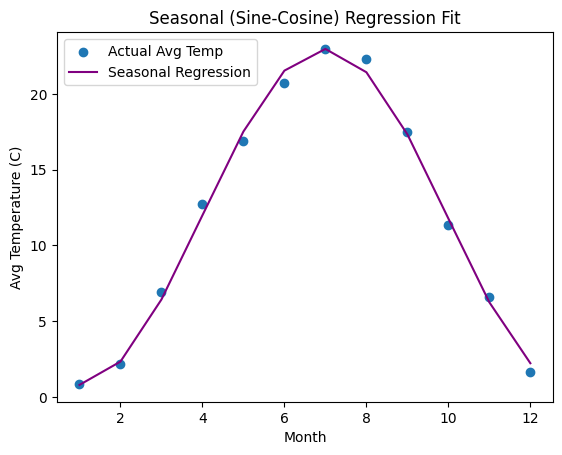

In [20]:
plt.scatter(months, temps, label="Actual Avg Temp")
plt.plot(months, y_pred_seasonal, label="Seasonal Regression", color='purple')
plt.xlabel("Month")
plt.ylabel("Avg Temperature (C)")
plt.title("Seasonal (Sine-Cosine) Regression Fit")
plt.legend()
plt.show()


In [21]:
X = months
Y = temps.reshape(-1,1)

x = 2 * np.pi * X / 12

X_fourier = np.column_stack((
    np.ones(len(X)),
    np.sin(x), np.cos(x),
    np.sin(2*x), np.cos(2*x)
))

X_fourier[:5]


array([[ 1.00000000e+00,  5.00000000e-01,  8.66025404e-01,
         8.66025404e-01,  5.00000000e-01],
       [ 1.00000000e+00,  8.66025404e-01,  5.00000000e-01,
         8.66025404e-01, -5.00000000e-01],
       [ 1.00000000e+00,  1.00000000e+00,  6.12323400e-17,
         1.22464680e-16, -1.00000000e+00],
       [ 1.00000000e+00,  8.66025404e-01, -5.00000000e-01,
        -8.66025404e-01, -5.00000000e-01],
       [ 1.00000000e+00,  5.00000000e-01, -8.66025404e-01,
        -8.66025404e-01,  5.00000000e-01]])

In [22]:
B = np.linalg.inv(X_fourier.T @ X_fourier) @ X_fourier.T @ Y
B


array([[11.88537558],
       [-5.45779812],
       [-9.66634826],
       [ 0.10418718],
       [-0.45798879]])

In [23]:
y_pred_fourier = (X_fourier @ B).flatten()
y_pred_fourier


array([ 0.64640772,  2.64483277,  6.88556625, 12.13072354, 17.20855654,
       21.09373506, 22.84681215, 21.76436467, 17.80116249, 11.91755892,
        5.92374835,  1.76103853])

In [24]:
mse = np.mean((temps - y_pred_fourier) ** 2)
mae = np.mean(np.abs(temps - y_pred_fourier))
r2 = 1 - (np.sum((temps - y_pred_fourier) ** 2) / np.sum((temps - np.mean(temps)) ** 2))

print("Fourier Model Results")
print("MSE:", mse)
print("MAE:", mae)
print("R-Square:", r2)


Fourier Model Results
MSE: 0.1786003797800775
MAE: 0.3657294381150349
R-Square: 0.9971147802582238


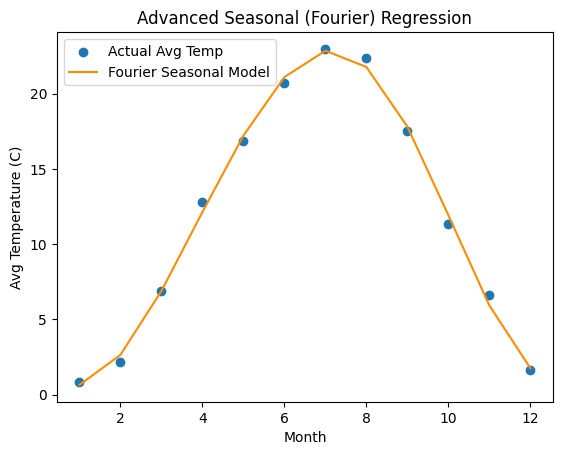

In [25]:
plt.scatter(months, temps, label="Actual Avg Temp")
plt.plot(months, y_pred_fourier, label="Fourier Seasonal Model", color='darkorange')
plt.xlabel("Month")
plt.ylabel("Avg Temperature (C)")
plt.title("Advanced Seasonal (Fourier) Regression")
plt.legend()
plt.show()


In [27]:
y_pred
y_pred_poly
y_pred_seasonal
y_pred_fourier


array([ 0.64640772,  2.64483277,  6.88556625, 12.13072354, 17.20855654,
       21.09373506, 22.84681215, 21.76436467, 17.80116249, 11.91755892,
        5.92374835,  1.76103853])

In [28]:
def evaluate_model(name, y_true, y_pred):
    mse = np.mean((y_true - y_pred) ** 2)
    mae = np.mean(np.abs(y_true - y_pred))
    r2 = 1 - (np.sum((y_true - y_pred) ** 2) / np.sum((y_true - np.mean(y_true)) ** 2))
    
    return [name, mse, mae, r2]


In [30]:
results = []

results.append(evaluate_model("Linear", temps, y_pred))
results.append(evaluate_model("Polynomial", temps, y_pred_poly))
results.append(evaluate_model("Seasonal", temps, y_pred_seasonal))
results.append(evaluate_model("Fourier", temps, y_pred_fourier))

import pandas as pd
comparison_df = pd.DataFrame(results, columns=["Model", "MSE", "MAE", "R-Square"])
comparison_df


,Model,MSE,MAE,R-Square
0,Linear,59.736051,6.977994,0.034987
1,Polynomial,4.965907,1.926056,0.919778
2,Seasonal,0.288905,0.449000,0.995333
3,Fourier,0.178600,0.365729,0.997115


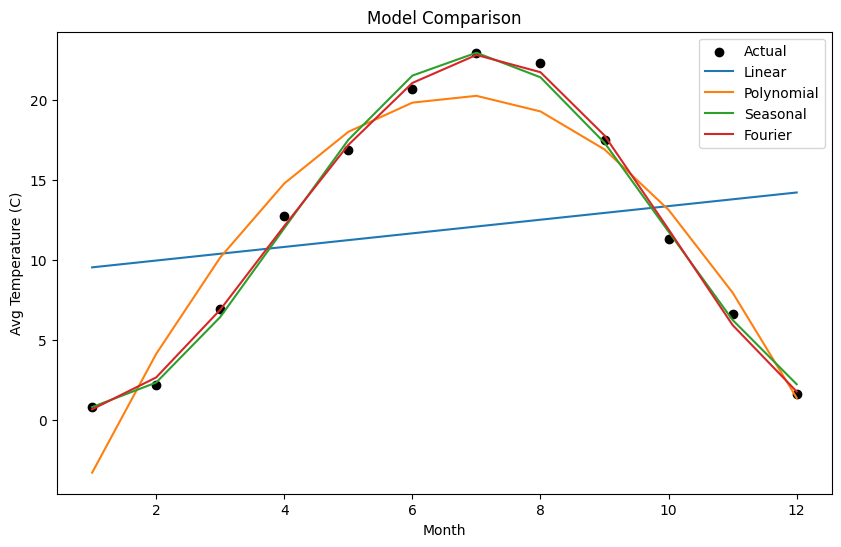

In [31]:
plt.figure(figsize=(10,6))
plt.scatter(months, temps, color='black', label='Actual')

plt.plot(months, y_pred, label='Linear')
plt.plot(months, y_pred_poly, label='Polynomial')
plt.plot(months, y_pred_seasonal, label='Seasonal')
plt.plot(months, y_pred_fourier, label='Fourier')

plt.xlabel("Month")
plt.ylabel("Avg Temperature (C)")
plt.title("Model Comparison")
plt.legend()
plt.show()
